Отримуємо курс USD від НБУ за останні 7 днів...


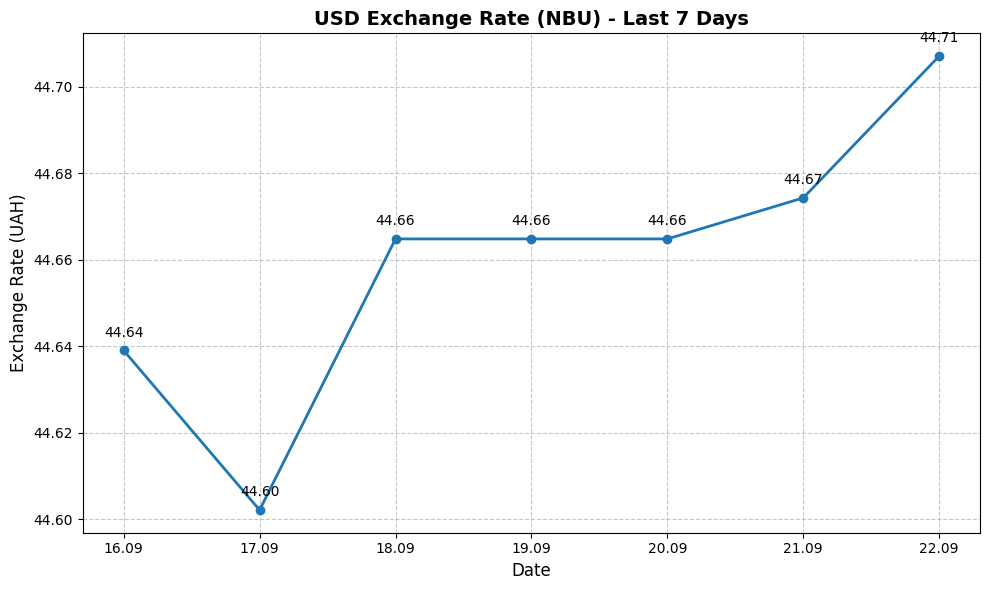

In [2]:
import requests # Бібліотека для того, щоб завантажувати дані з інтернету (робити HTTP-запити до сайту НБУ)
import matplotlib.pyplot as plt # Бібліотека для малювання самого графіка
from datetime import datetime, timedelta # Інструменти для роботи з часом та датами

def fetch_and_plot_nbu_rates(currency_code="USD", days=7):
    # Створюємо порожні списки. Сюди ми будемо складати дані, які отримаємо з сайту
    dates = [] # Тут ми будемо зберігати дати (це буде вісь Х на графіку)
    rates = [] # А тут - сам курс валют (це буде вісь Y на графіку)

    print(f"Отримуємо курс {currency_code} від НБУ за останні {days} днів...")

    # Запускаємо цикл, який пройдеться по кожному з останніх 7 днів у зворотному порядку (щоб графік йшов зліва направо)
    for i in range(days, 0, -1):
        # Віднімаємо від сьогоднішньої дати потрібну кількість днів
        target_date = datetime.now() - timedelta(days=i)

        # Форматуємо дату так, як того вимагає сайт НБУ (наприклад, 20231025)
        date_str = target_date.strftime("%Y%m%d")

        # Форматуємо дату для нашого графіка, щоб було красиво (день.місяць, наприклад 25.10)
        display_date = target_date.strftime("%d.%m")

        # Це посилання (URL) до API НБУ. Ми підставляємо сюди назву валюти і дату
        url = f"https://bank.gov.ua/NBUStatService/v1/statdirectory/exchange?valcode={currency_code}&date={date_str}&json"

        try:
            # Звертаємося до сайту НБУ і просимо віддати нам дані
            response = requests.get(url)
            response.raise_for_status() # Перевіряємо, чи немає помилки (наприклад, чи не відпав інтернет)

            # Перетворюємо відповідь сайту у зручний для пайтона формат словника (JSON)
            data = response.json()

            # Якщо сайт дійсно повернув нам дані, додаємо їх у наші списки
            if data:
                rates.append(data[0]['rate']) # Забираємо саме число курсу з відповіді
                dates.append(display_date) # Зберігаємо дату
            else:
                print(f"Немає даних за {display_date}")

        except requests.exceptions.RequestException as e:
            # Якщо щось пішло не так, програма не видасть критичну помилку і не вилетить, а просто напише про це і піде далі
            print(f"Помилка завантаження даних за {display_date}: {e}")

    # Коли цикл закінчився і всі дані зібрані, починаємо малювати графік
    if rates and dates:
        # Створюємо "полотно" для графіка розміром 10 на 6
        plt.figure(figsize=(10, 6))

        # Малюємо лінію з точками (marker='o'). Передаємо наші збережені дати та курси.
        plt.plot(dates, rates, marker='o', linestyle='-', color='#1f77b4', linewidth=2)

        # Підписи для графіка (залишені англійською за умовами завдання)
        plt.title(f"{currency_code} Exchange Rate (NBU) - Last {days} Days", fontsize=14, fontweight='bold')
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Exchange Rate (UAH)", fontsize=12)

        # Цей цикл підписує кожну точку на графіку цифрами, щоб було видно точний курс
        for i, rate in enumerate(rates):
            plt.annotate(f"{rate:.2f}", (dates[i], rates[i]), textcoords="offset points", xytext=(0,10), ha='center')

        # Додаємо сітку на задній фон, щоб було легше орієнтуватися по значеннях
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout() # Автоматично підганяє відступи, щоб нічого не вилазило за краї вікна

        # Відмальовуємо і показуємо готовий графік на екрані
        plt.show()
    else:
        print("Недостатньо даних для побудови графіка.")

# Ця конструкція означає: якщо ми запускаємо саме цей файл прямо, то треба викликати нашу головну функцію
if __name__ == "__main__":
    fetch_and_plot_nbu_rates()